In [6]:
!pip install streamlit matplotlib pandas


In [7]:


import pandas as pd
import matplotlib.pyplot as plt


In [8]:
df = pd.read_csv(r"C:\Users\Aziz\Downloads\netflix_titles (1).csv")

In [9]:
df = df.drop_duplicates()

In [10]:
df['director'].fillna("Inconnu", inplace=True)
df['cast'].fillna("Inconnu", inplace=True)
df['country'].fillna("Inconnu", inplace=True)
df['rating'].fillna("Non classé", inplace=True)


In [11]:
df = df.dropna(subset=['date_added'])

In [12]:
df['date_added'] = df['date_added'].str.strip()


In [13]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [14]:
df['year_added'] = df['date_added'].dt.year

In [15]:
options=df['type'].unique()
default=df['type'].unique()

In [16]:
int(df['release_year'].min()),
int(df['release_year'].max()),

(2021,)

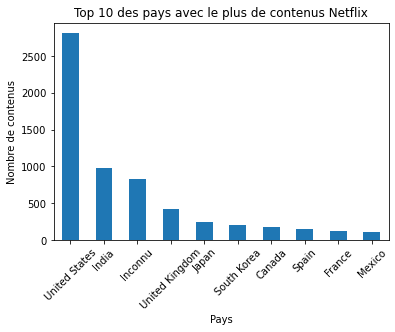

In [17]:
top_countries = df["country"].value_counts().head(10)

top_countries.plot(kind="bar")

plt.title("Top 10 des pays avec le plus de contenus Netflix")
plt.xlabel("Pays")
plt.ylabel("Nombre de contenus")

plt.xticks(rotation=45)

plt.show()

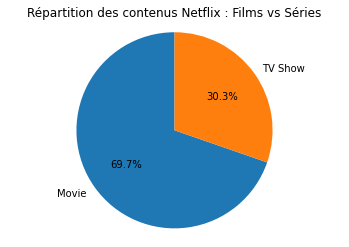

In [18]:
types = df["type"].value_counts()

plt.figure(facecolor="white")

plt.pie(types,
        labels=types.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Répartition des contenus Netflix : Films vs Séries")

plt.axis("equal")

plt.show()


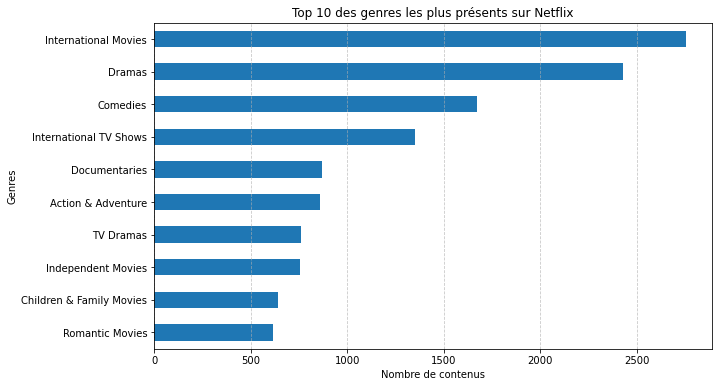

In [19]:
genres = df["listed_in"].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

top_genres.sort_values().plot(kind="barh")

plt.title("Top 10 des genres les plus présents sur Netflix")
plt.xlabel("Nombre de contenus")
plt.ylabel("Genres")

plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()

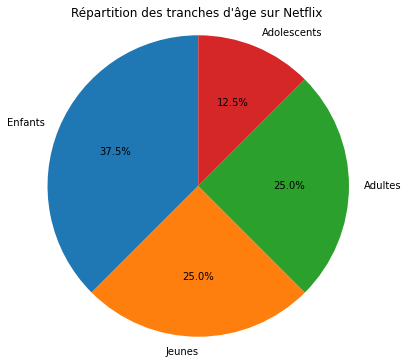

In [20]:
ages = df["rating"].value_counts()

mapping = {
    "G": "Enfants",
    "TV-Y": "Enfants",
    "TV-Y7": "Enfants",
    "PG": "Jeunes",
    "TV-PG": "Jeunes",
    "TV-14": "Adolescents",
    "R": "Adultes",
    "TV-MA": "Adultes"
}

ages = ages.index.to_series().map(mapping).value_counts()

plt.figure(figsize=(6,6), facecolor="white")

plt.pie(
    ages,
    labels=ages.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Répartition des tranches d'âge sur Netflix")

plt.axis("equal")

plt.show()


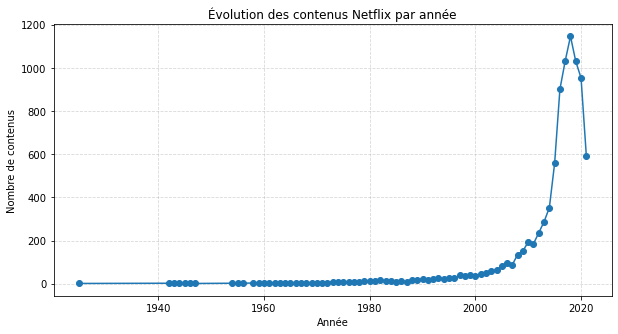

In [21]:
years = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))

years.plot(kind="line", marker="o")

plt.title("Évolution des contenus Netflix par année")
plt.xlabel("Année")
plt.ylabel("Nombre de contenus")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

<ipython-input-22-af25abd46128>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies["duration"] = movies["duration"].str.replace(" min", "")
<ipython-input-22-af25abd46128>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")


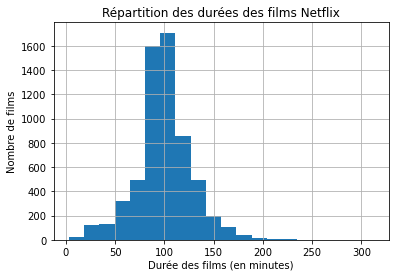

In [22]:
movies = df[df["type"] == "Movie"]

movies["duration"] = movies["duration"].str.replace(" min", "")
movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

movies["duration"].hist(bins=20)

plt.title("Répartition des durées des films Netflix")
plt.xlabel("Durée des films (en minutes)")
plt.ylabel("Nombre de films")

plt.show()